# Parkinson's Disease Detection

This project uses machine learning to detect Parkinson's disease based on biomedical voice measurements.

## Objective

The objective is to build a classification model that predicts whether a person has Parkinson's disease using voice-related features.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Data collection and analysis

In [2]:
parkinson_data = pd.read_csv("data/parkinsons.csv")

In [3]:
parkinson_data.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


## Target Variable

- **1** → Person has Parkinson's disease  
- **0** → Person does not have Parkinson's disease

In [4]:
parkinson_data.shape

(195, 24)

In [5]:
parkinson_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [6]:
parkinson_data.isnull().sum()

,0
name,0
MDVP:Fo(Hz),0
MDVP:Fhi(Hz),0
MDVP:Flo(Hz),0
MDVP:Jitter(%),0
MDVP:Jitter(Abs),0
MDVP:RAP,0
MDVP:PPQ,0
Jitter:DDP,0
MDVP:Shimmer,0


In [7]:
parkinson_data.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [8]:
parkinson_data['status'].value_counts()

,count
status,
1,147
0,48


In [9]:
parkinson_data.groupby('status').mean(numeric_only=True)

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
status,,,,,,,,,,,,,,,,,,,,,
0,181.937771,223.636750,145.207292,0.003866,0.000023,0.001925,0.002056,0.005776,0.017615,0.162958,...,0.013305,0.028511,0.011483,24.678750,0.442552,0.695716,-6.759264,0.160292,2.154491,0.123017
1,145.180762,188.441463,106.893558,0.006989,0.000051,0.003757,0.003900,0.011273,0.033658,0.321204,...,0.027600,0.053027,0.029211,20.974048,0.516816,0.725408,-5.333420,0.248133,2.456058,0.233828


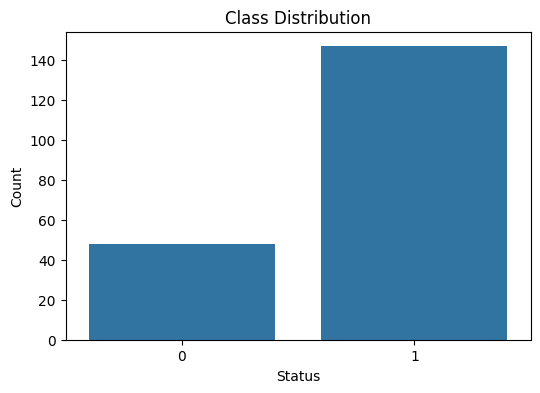

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x="status", data=parkinson_data)
plt.title("Class Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

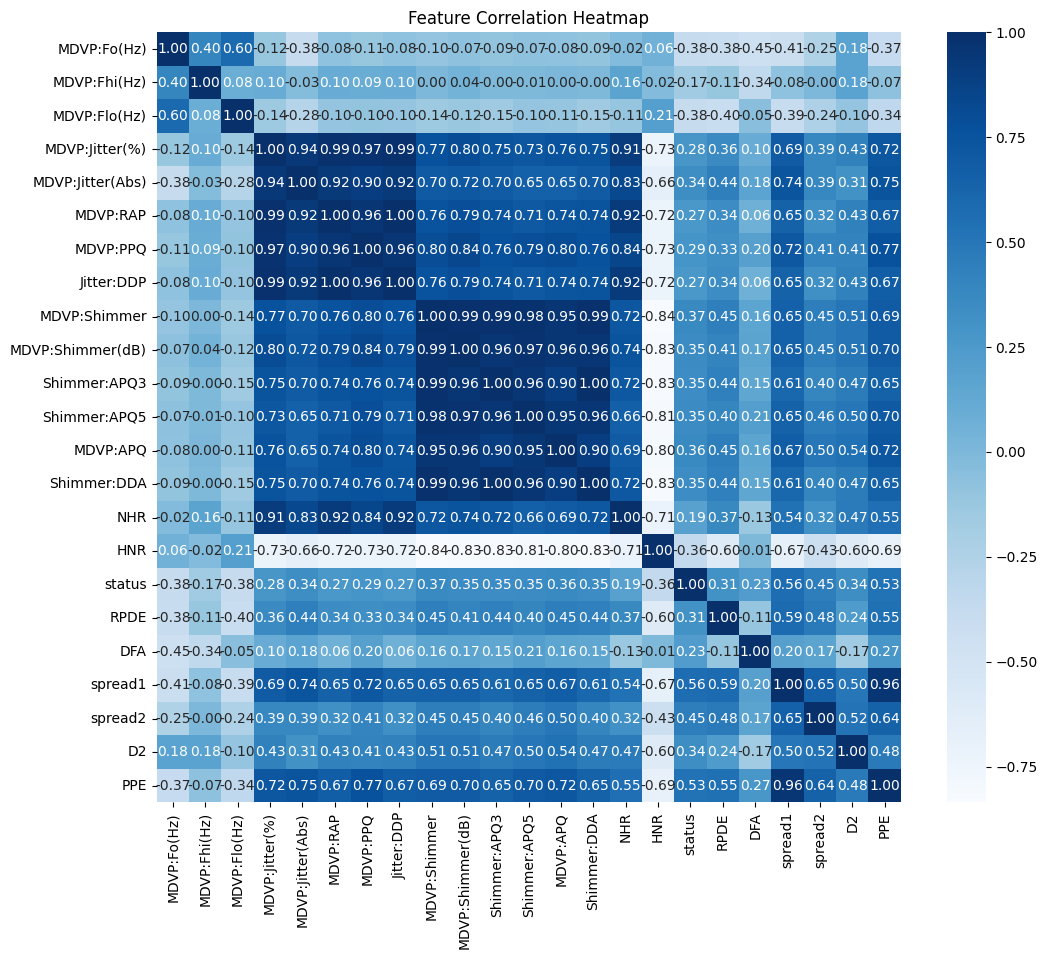

In [11]:
plt.figure(figsize=(12, 10))
sns.heatmap(parkinson_data.drop(columns=["name"]).corr(),annot=True, cmap="Blues",fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

Data Pre-Processing

In [12]:
X = parkinson_data.drop(columns=["name","status"],axis=1)
Y = parkinson_data['status']

In [13]:
print(X.shape)
print(Y.shape)

(195, 22)
(195,)


Splitting the data into training and test data

In [14]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [15]:
print(X.shape,X_test.shape,X_train.shape)

(195, 22) (39, 22) (156, 22)


Data Standardization

In [16]:
scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [17]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

Model Training

In [18]:
model = svm.SVC(kernel='linear')

In [19]:
model.fit(X_train,Y_train)

SVC(kernel='linear')

In [20]:
training_data_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(Y_train,training_data_prediction)

print(f"Accuracy score of training data : {training_data_accuracy}")

Accuracy score of training data : 0.9038461538461539


In [21]:
test_data_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(Y_test,test_data_prediction)

print(f"Accuracy score of test data : {test_data_accuracy}")

Accuracy score of test data : 0.9487179487179487


In [22]:
print(classification_report(Y_test, test_data_prediction))

              precision    recall  f1-score   support

           0       1.00      0.80      0.89        10
           1       0.94      1.00      0.97        29

    accuracy                           0.95        39
   macro avg       0.97      0.90      0.93        39
weighted avg       0.95      0.95      0.95        39



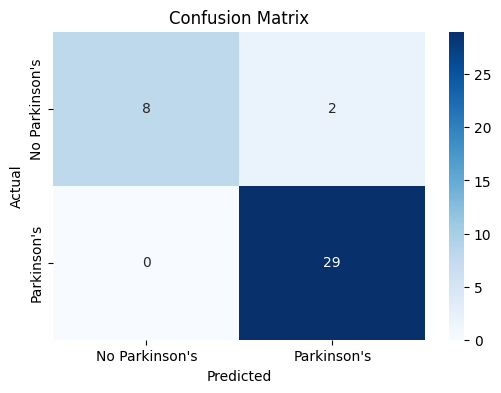

In [23]:
cm = confusion_matrix(Y_test, test_data_prediction)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Parkinson's", "Parkinson's"],
            yticklabels=["No Parkinson's", "Parkinson's"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [24]:
rbf_model = svm.SVC(kernel="rbf")
rbf_model.fit(X_train, Y_train)

rbf_prediction = rbf_model.predict(X_test)

print("RBF SVM Accuracy:", accuracy_score(Y_test, rbf_prediction))
print(classification_report(Y_test, rbf_prediction))

RBF SVM Accuracy: 0.9230769230769231
              precision    recall  f1-score   support

           0       1.00      0.70      0.82        10
           1       0.91      1.00      0.95        29

    accuracy                           0.92        39
   macro avg       0.95      0.85      0.89        39
weighted avg       0.93      0.92      0.92        39



In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": ["Linear SVM", "RBF SVM"],
    "Accuracy": [
        accuracy_score(Y_test, test_data_prediction),
        accuracy_score(Y_test, rbf_prediction)
    ],
    "Precision": [
        precision_score(Y_test, test_data_prediction),
        precision_score(Y_test, rbf_prediction)
    ],
    "Recall": [
        recall_score(Y_test, test_data_prediction),
        recall_score(Y_test, rbf_prediction)
    ],
    "F1 Score": [
        f1_score(Y_test, test_data_prediction),
        f1_score(Y_test, rbf_prediction)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.948718,0.935484,1.0,0.966667
1,RBF SVM,0.923077,0.906250,1.0,0.950820


In [26]:
sample = X.iloc[[0]]
sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

if prediction[0] == 1:
    print("Prediction: Parkinson's Disease Detected")
else:
    print("Prediction: No Parkinson's Disease Detected")

print("Actual:", "Parkinson's Disease" if Y.iloc[0] == 1 else "No Parkinson's Disease")

Prediction: Parkinson's Disease Detected
Actual: Parkinson's Disease


## Conclusion

In this project, Parkinson's disease detection was performed using machine learning.

- The dataset contained 195 records and 24 columns.
- Biomedical voice features were used for classification.
- The dataset was imbalanced, with more Parkinson's cases than non-Parkinson's cases.
- Features were standardized using StandardScaler.
- Linear SVM and RBF SVM models were trained and compared.
- Linear SVM achieved the best test accuracy of approximately 94.87%.
- Evaluation was performed using accuracy, precision, recall, F1-score, classification report, and confusion matrix.
- The final model and scaler were saved for deployment.

> Note: This project is for educational purposes only and should not be used for real medical diagnosis.

In [27]:
import pickle

with open("parkinsons_model.pkl", "wb") as file:
    pickle.dump(model, file)

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)